# AMD Stock Price Prediction

Name: Leonardus Hasan

NIM: 2802553480

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("AMD.csv")

## EDA

In [3]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-03-17,0.0,3.302083,3.125000,3.145833,3.145833,219600
1,1980-03-18,0.0,3.125000,2.937500,3.031250,3.031250,727200
2,1980-03-19,0.0,3.083333,3.020833,3.041667,3.041667,295200
3,1980-03-20,0.0,3.062500,3.010417,3.010417,3.010417,159600
4,1980-03-21,0.0,3.020833,2.906250,2.916667,2.916667,130800


In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
10093,2020-03-26,45.779999,47.500000,45.400002,47.500000,47.500000,73680200
10094,2020-03-27,46.320000,47.980000,45.900002,46.580002,46.580002,74599200
10095,2020-03-30,47.240002,48.459999,46.660000,47.860001,47.860001,68486600
10096,2020-03-31,47.930000,48.529999,45.160000,45.480000,45.480000,83483700
10097,2020-04-01,44.180000,46.849998,43.160000,43.660000,43.660000,91895000


This dataset consists of AMD stock data spanning from December 12, 1980, to April 1, 2020. An examination of the first five data points reveals that the opening price is recorded as 0; this likely occurred because the opening price data was unavailable at the time and was consequently replaced with a placeholder value of 0. However, since the opening price column is not utilized in this specific case, it can be disregarded.

In [3]:
df = df[['Date', 'Close']]

In [6]:
df.describe()

,Close
count,10098.000000
mean,11.210802
std,8.283645
min,1.620000
25%,4.937500
50%,9.062500
75%,14.707500
max,58.900002


This stock has the lowest closing price of 0.196, an average closing price of 32.618, and a highest price of 327.2.

In [7]:
df.isna().sum()

Date     0
Close    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9909 non-null   object 
 1   Close   9909 non-null   float64
dtypes: float64(1), object(1)
memory usage: 155.0+ KB


The 'date' column is currently of the object type. Since it represents a date, it needs to be converted to the date type.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.head(5)

,Date,Close
0,1980-03-17,3.145833
1,1980-03-18,3.031250
2,1980-03-19,3.041667
3,1980-03-20,3.010417
4,1980-03-21,2.916667


The stock data above is already sorted by date. Therefore, we no longer need to sort the dates from beginning to end.

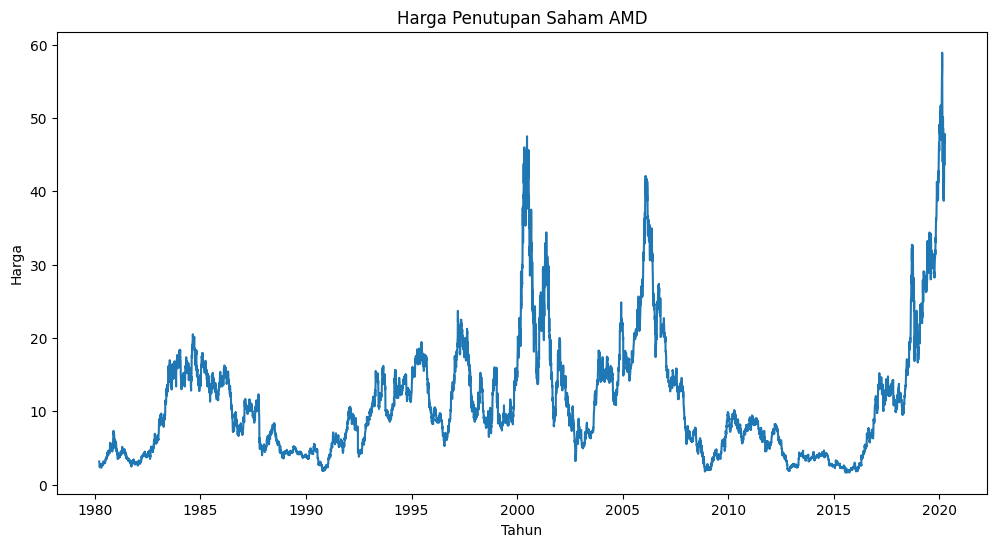

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Harga Penutupan Saham AMD")
plt.xlabel("Tahun")
plt.ylabel("Harga")
plt.show()

Based on the graph above, the following information can be observed:
- The stock data is time-series data spanning the period from 1980 to 2020.
- The stock price exhibits fluctuations, meaning it shows upward and downward movements over the given timeframe.
- The AMD stock price trend indicates that both bullish and bearish phases have occurred since 1980 (bullish: a trend of rising stock prices; bearish: a trend of falling stock prices).
- The stock data is non-stationary, as there are trends of rising and falling prices across various time intervals.

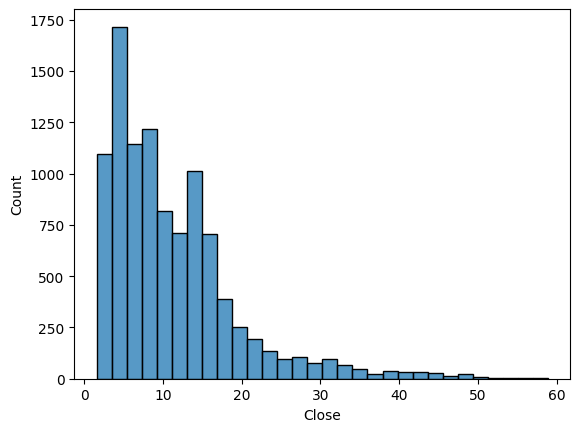

In [12]:
sns.histplot(df['Close'], bins=30)
plt.show()

The dataset appears left-skewed regarding closing prices (approximately 0–1). This is because, based on stock price movement patterns between 1980 and 2005, the closing prices fell within a relatively low range, causing the data to skew to the left.

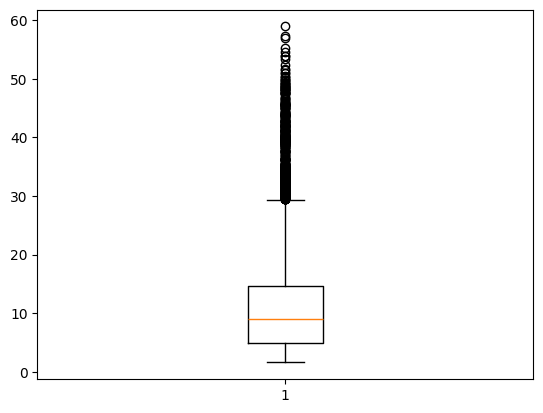

In [13]:
plt.boxplot(df['Close'])
plt.show()

Outliers were detected in this stock dataset. However, this is normal and expected, as the data consists of stock figures; high closing prices simply reflect market conditions at the time. Therefore, the outliers have been retained to enable the LSTM model to learn the patterns of stock price movements.

## Preprocessing

The stock data is current as of April 1, 2020. Therefore, the test data begins on April 1, 2019, while the training data spans the period from December 12, 1980, to March 29, 2019.

In [5]:
train = df[df['Date'] < '2019-04-01']
test = df[df['Date'] >= '2019-04-01']

In [15]:
test

,Date,Close
9844,2019-04-01,26.360001
9845,2019-04-02,26.750000
9846,2019-04-03,29.020000
9847,2019-04-04,29.090000
9848,2019-04-05,28.980000
...,...,...
10093,2020-03-26,47.500000
10094,2020-03-27,46.580002
10095,2020-03-30,47.860001
10096,2020-03-31,45.480000


In [16]:
train

,Date,Close
0,1980-03-17,3.145833
1,1980-03-18,3.031250
2,1980-03-19,3.041667
3,1980-03-20,3.010417
4,1980-03-21,2.916667
...,...,...
9839,2019-03-25,25.969999
9840,2019-03-26,25.690001
9841,2019-03-27,24.889999
9842,2019-03-28,25.059999


In [6]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['Close']])
test_scaled = scaler.transform(test[['Close']])

In [7]:
def input_output(data, window=5):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [8]:
X_train_temp, y_train_temp = input_output(train_scaled)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.1, shuffle=False)

In [20]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(8855, 5, 1)
(8855, 1)
(984, 5, 1)
(984, 1)


After splitting the training data into training and validation sets, 8,685 samples were obtained for training and 965 samples for validation. Each sample has a shape of (5, 1), meaning it consists of five closing price data points from five trading days as input—comprising a single feature (the closing value)—while the target to be predicted is the closing price of the following day (horizon = 1).

In [9]:
combined = np.concatenate([train_scaled[-5:], test_scaled])
X_test, y_test = input_output(combined)

In [22]:
print(X_test.shape)
print(y_test.shape)

(254, 5, 1)
(254, 1)


In [10]:
baseline = Sequential([LSTM(units=50, activation='relu', input_shape=(5,1)), Dense(1)])
baseline.compile(optimizer='adam', loss='mse',metrics=['mae'])

In [11]:
history = baseline.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=50, batch_size=32, verbose=1)

Epoch 1/50
277/277 [==============================] - 19s 41ms/step - loss: 0.0045 - mae: 0.0279 - val_loss: 3.4287e-04 - val_mae: 0.0118
Epoch 2/50
277/277 [==============================] - 10s 36ms/step - loss: 2.6161e-04 - mae: 0.0100 - val_loss: 2.9475e-04 - val_mae: 0.0104
Epoch 3/50
277/277 [==============================] - 10s 35ms/step - loss: 2.4880e-04 - mae: 0.0098 - val_loss: 3.0703e-04 - val_mae: 0.0108
Epoch 4/50
277/277 [==============================] - 10s 35ms/step - loss: 2.4144e-04 - mae: 0.0096 - val_loss: 3.3696e-04 - val_mae: 0.0114
Epoch 5/50
277/277 [==============================] - 10s 34ms/step - loss: 2.3297e-04 - mae: 0.0095 - val_loss: 2.7533e-04 - val_mae: 0.0113
Epoch 6/50
277/277 [==============================] - 10s 35ms/step - loss: 2.1851e-04 - mae: 0.0092 - val_loss: 2.5312e-04 - val_mae: 0.0100
Epoch 7/50
277/277 [==============================] - 10s 35ms/step - loss: 2.1174e-04 - mae: 0.0090 - val_loss: 2.6175e-04 - val_mae: 0.0096
Epoch 8/50

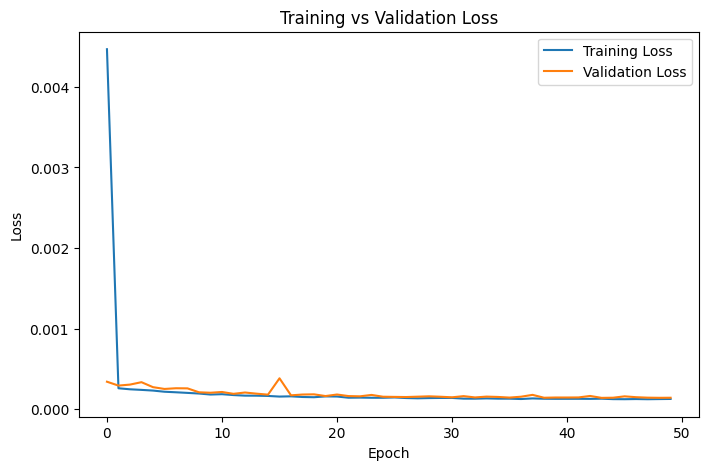

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Based on the LOSS graph above, the following conclusions can be drawn:
- The training loss dropped sharply during the first epoch before approaching zero.
- Both the training and loss graphs indicate an absence of overfitting.
- The model is capable of learning from the training and validation data very effectively.

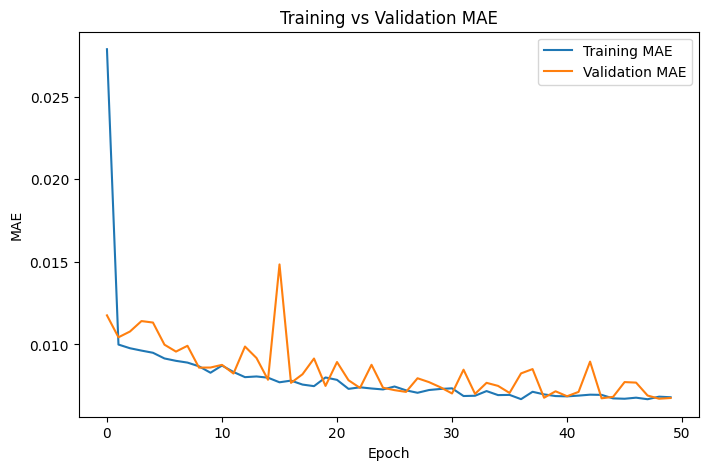

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

The results shown in the Training vs. Validation MAE graph above are quite similar to those of the training vs. validation loss graph; both the training and validation data were learned effectively, despite minor fluctuations in the validation MAE. This indicates that the model's ability to generalize to the data is highly optimal.

Therefore, the next stage of model development will involve architectural modifications or hyperparameter adjustments, such as:
- Changing the activation function from ReLU to Tanh. Tanh constrains output values ​​to the range of -1 to 1, which can lead to a much more stable and smooth training process.
- Implementing EarlyStopping to halt training when validation loss ceases to improve.
- Adjusting the number of LSTM units to provide the model with greater representational capacity for learning stock price movement patterns.

In [42]:
modified = Sequential([LSTM(63, activation='tanh', input_shape=(5,1)), Dense(1)])
modified.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [43]:
es = EarlyStopping(monitor='val_loss',patience=8, restore_best_weights=True)

In [44]:
history = modified.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[es], shuffle=False)

Epoch 1/50
277/277 [==============================] - 9s 23ms/step - loss: 0.0029 - mae: 0.0390 - val_loss: 0.0047 - val_mae: 0.0516
Epoch 2/50
277/277 [==============================] - 4s 15ms/step - loss: 8.0577e-04 - mae: 0.0201 - val_loss: 0.0032 - val_mae: 0.0429
Epoch 3/50
277/277 [==============================] - 5s 16ms/step - loss: 5.1583e-04 - mae: 0.0160 - val_loss: 0.0022 - val_mae: 0.0352
Epoch 4/50
277/277 [==============================] - 5s 17ms/step - loss: 4.0083e-04 - mae: 0.0137 - val_loss: 0.0015 - val_mae: 0.0281
Epoch 5/50
277/277 [==============================] - 5s 17ms/step - loss: 3.5346e-04 - mae: 0.0125 - val_loss: 0.0012 - val_mae: 0.0246
Epoch 6/50
277/277 [==============================] - 4s 15ms/step - loss: 3.4014e-04 - mae: 0.0120 - val_loss: 0.0011 - val_mae: 0.0236
Epoch 7/50
277/277 [==============================] - 4s 16ms/step - loss: 3.4072e-04 - mae: 0.0119 - val_loss: 0.0011 - val_mae: 0.0234
Epoch 8/50
277/277 [=========================

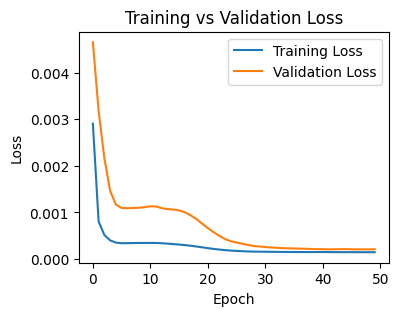

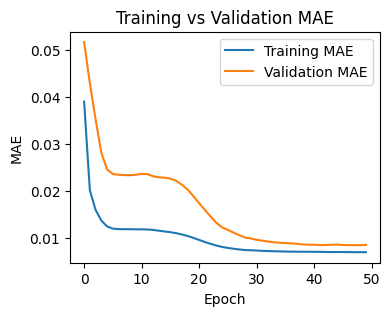

In [45]:
plt.figure(figsize=(4,3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(4,3))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

Based on the Training vs. Validation Loss and Training vs. Validation MAE graphs above, the following points can be outlined:
- Following the architectural modifications, the model became increasingly capable of learning price movement patterns. This is evidenced by the decrease in both training loss and validation loss.
- The model underwent a second convergence phase after the 25th epoch, during which validation loss and MAE dropped significantly again after having plateaued earlier in the training process.

In [47]:
y_pred_baseline = baseline.predict(X_test)
y_pred_modified = modified.predict(X_test)

y_true = scaler.inverse_transform(y_test)
y_pred_baseline = scaler.inverse_transform(y_pred_baseline)
y_pred_modified = scaler.inverse_transform(y_pred_modified)

8/8 [==============================] - 1s 9ms/step


In [34]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mae = mean_absolute_error(y_true, y_pred_baseline)
mape = mean_absolute_percentage_error(y_true, y_pred_baseline) * 100

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 1.5463
MAE  : 1.0814
MAPE : 2.86%


In [48]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred_modified))
mae = mean_absolute_error(y_true, y_pred_modified)
mape = mean_absolute_percentage_error(y_true, y_pred_modified) * 100

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 2.6532
MAE  : 2.1858
MAPE : 5.72%


The graphs reveal that the training loss and validation loss lines converge as they approach the 30th epoch, indicating that both the baseline and modified models possess good generalization capabilities. A similar trend is observed in the baseline model's graph, where the validation MAE curve closely tracks the training MAE curve; this suggests the model rapidly learns data patterns during the initial stages of training. The modified model also demonstrates excellent performance from the 25th epoch onwards, despite a relatively larger gap between training and validation metrics during the early stages up to approximately the 25th epoch. This gap subsequently narrows, showing no significant signs of overfitting. Overall, the diminishing difference between training and validation curves throughout the process indicates that both models exhibit strong generalization capabilities.

Nevertheless, the baseline model outperforms the modified model in terms of RMSE, MAE, and MAPE results. A lower RMSE (1.5463 < 2.6532) indicates predictions closer to actual values; a lower MAE (1.0814 < 2.1858) signifies greater prediction accuracy; and a lower MAPE (2.86% < 5.72%) reflects a lower percentage error. The higher values ​​for these three parameters in the modified model may stem from increased model complexity that has not yet yielded an optimal configuration for this specific dataset, resulting in metrics that are inferior to those of the baseline model.

Consequently, the baseline model demonstrates superior prediction accuracy compared to the modified model.

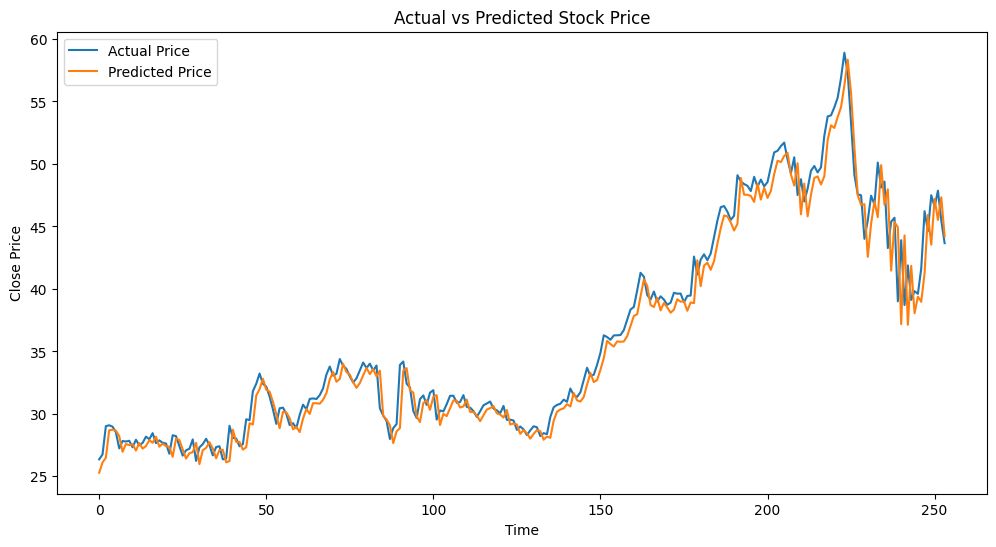

In [49]:
plt.figure(figsize=(12,6))

plt.plot(y_true, label='Actual Price')
plt.plot(y_pred_baseline, label='Predicted Price')

plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()

plt.show()

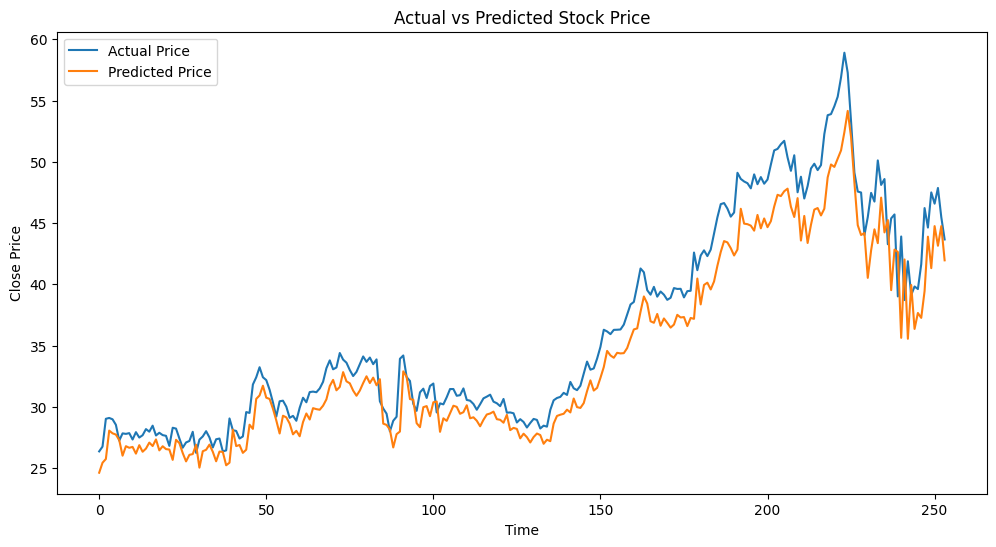

In [50]:
plt.figure(figsize=(12,6))

plt.plot(y_true, label='Actual Price')
plt.plot(y_pred_modified, label='Predicted Price')

plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()

plt.show()